In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from statsmodels.stats.diagnostic import acorr_ljungbox

import seaborn as sns

## Load Predictions

In [2]:
forecast_df = pd.read_csv(
    "../../data/processed/Sales_forcasting_data/sarima_predictions.csv",
    index_col=0,
    parse_dates=True
)

forecast_df.head()

,Actual,Predicted
2018-04-29,269879.70,260546.397830
2018-05-06,277743.55,258016.020304
2018-05-13,334320.93,257083.579653
2018-05-20,295686.95,256739.976550
2018-05-27,152343.99,256613.359278


## Calculate the Evaluation Metrics

In [3]:
mae = mean_absolute_error(
    forecast_df["Actual"],
    forecast_df["Predicted"]
)

rmse = np.sqrt(
    mean_squared_error(
        forecast_df["Actual"],
        forecast_df["Predicted"]
    )
)

mape = mean_absolute_percentage_error(
    forecast_df["Actual"],
    forecast_df["Predicted"]
)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2%}")

MAE  : 45671.60
RMSE : 55941.80
MAPE : 21.79%


### Compare with baseline

In [4]:
comparison = pd.DataFrame({

    "Model":[
        "Naive Forecast",
        "Moving Average",
        "SARIMA (1,1,2)"
    ],

    "MAE":[
        46751.39,
        46143.30,
        mae
    ],

    "RMSE":[
        58302.94,
        55875.43,
        rmse
    ],

    "MAPE":[
        22.99,
        21.86,
        mape*100
    ]

})

comparison

,Model,MAE,RMSE,MAPE
0,Naive Forecast,46751.39000,58302.94000,22.990000
1,Moving Average,46143.30000,55875.43000,21.860000
2,"SARIMA (1,1,2)",45671.60222,55941.80144,21.788926


## Forecast Vs Actual

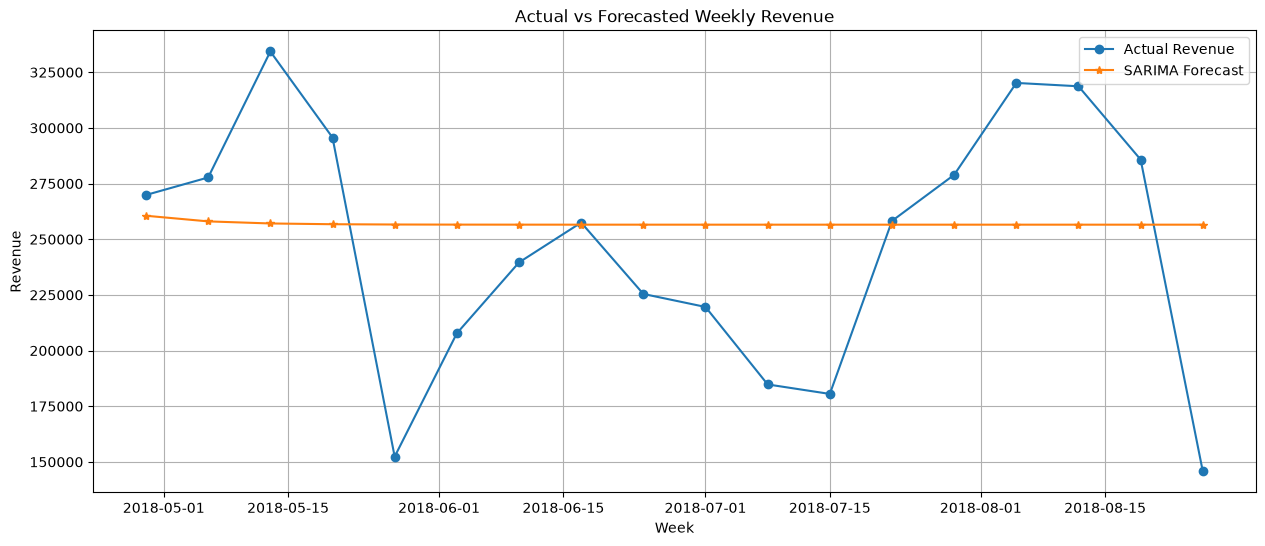

In [7]:
plt.figure(figsize=(15,6))

plt.plot(
    forecast_df.index,
    forecast_df["Actual"],
    marker = 'o',
    label="Actual Revenue"
)

plt.plot(
    forecast_df.index,
    forecast_df["Predicted"],
    marker = '*',
    label="SARIMA Forecast"
)

plt.title("Actual vs Forecasted Weekly Revenue")

plt.xlabel("Week")

plt.ylabel("Revenue")

plt.legend()

plt.grid(True)

plt.show()

## Residual Analysis
Residual = Actual − Predicted

In [8]:
forecast_df["Residual"] = (
    forecast_df["Actual"] -
    forecast_df["Predicted"]
)

### Residual Plot

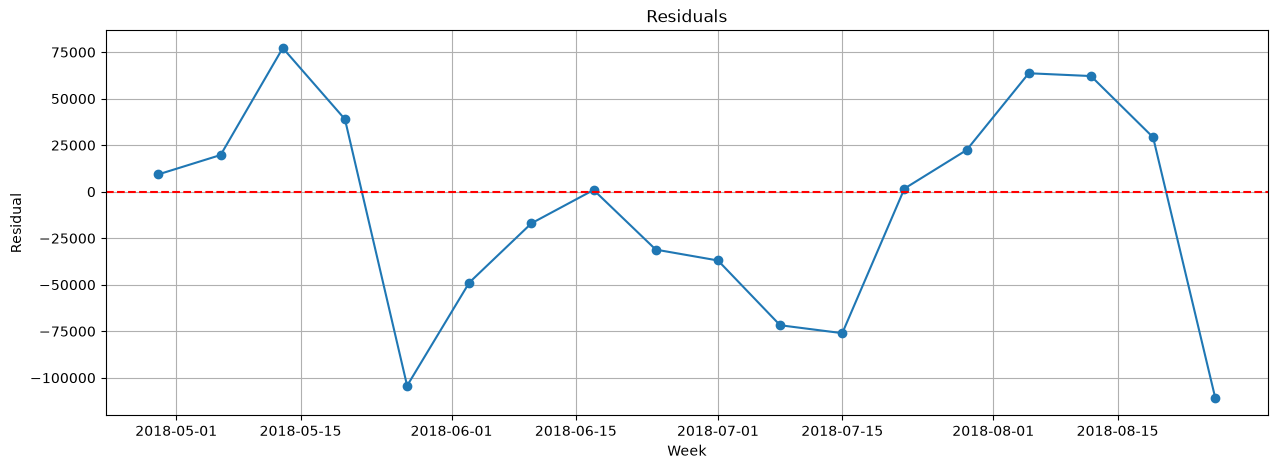

In [9]:
plt.figure(figsize=(15,5))

plt.plot(
    forecast_df.index,
    forecast_df["Residual"],
    marker="o"
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Residuals")

plt.xlabel("Week")

plt.ylabel("Residual")

plt.grid(True)

plt.show()

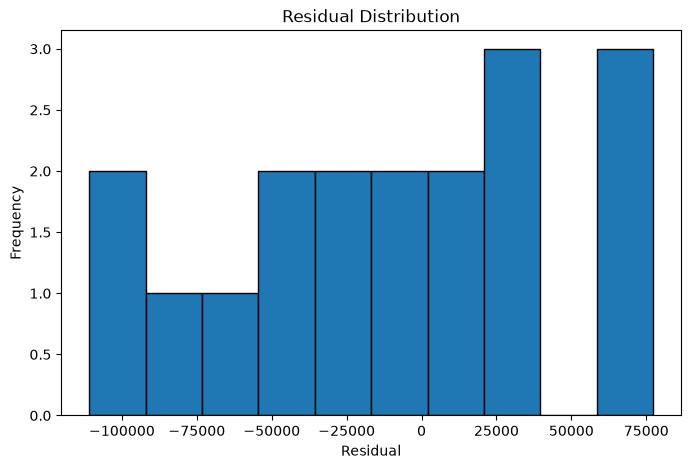

In [10]:
plt.figure(figsize=(8,5))

plt.hist(
    forecast_df["Residual"],
    bins=10,
    edgecolor="black"
)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.show()

## Ljung - Box Test

In [11]:
ljung = acorr_ljungbox(
    forecast_df["Residual"],
    lags=[10],
    return_df=True
)

ljung

,lb_stat,lb_pvalue
10,12.940519,0.227017


## Model Evaluation Summary

Three forecasting approaches were evaluated using the weekly sales revenue test dataset.

| Model | MAE | RMSE | MAPE |
|-------|----:|-----:|------:|
| Naïve Forecast | 46,751 | 58,303 | 22.99% |
| Moving Average | 46,143 | 55,875 | 21.86% |
| SARIMA (1,1,2) | 45,672 | 55,942 | 21.79% |

The SARIMA (1,1,2) model achieved the lowest Mean Absolute Error (MAE) and Mean Absolute Percentage Error (MAPE), indicating slightly better forecasting performance than the benchmark models.

Although the Moving Average model produced a marginally lower RMSE, the difference was negligible (<0.2%), suggesting comparable predictive accuracy.

Residual diagnostics were performed using the Ljung–Box test.

- **Ljung–Box p-value:** 0.227

Since the p-value exceeds 0.05, the null hypothesis of independent residuals cannot be rejected. This indicates that the residuals behave approximately as white noise, suggesting that the model has captured most of the temporal structure present in the historical sales data.

Overall, the SARIMA model provides a statistically sound and interpretable forecasting solution for the Olist weekly sales revenue dataset. However, forecasting accuracy is constrained by the relatively short time series and the absence of external explanatory variables such as promotions, holidays, and marketing campaigns.